# **Space X  Falcon 9 First Stage Landing Prediction**


In [1]:
# Import the necessary libraries
import pandas as pd # For data manipulation and analysis
import numpy             as np    # For numerical operations
import seaborn           as sns   # For plotting graphs and visualization
import matplotlib.pyplot as plt   # For plotting graphs and visualization

from sklearn.svm             import SVC                    # Support Vector Machine classification algorithm
from sklearn                 import preprocessing          # To standard size our data
from sklearn.model_selection import train_test_split       # To split our data into training and testing data
from sklearn.model_selection import GridSearchCV           # To test parameters of classification algorithms 
from sklearn.linear_model    import LogisticRegression     # For logistic Regression classification algorithm
from sklearn.tree            import DecisionTreeClassifier # For decision Tree classification algorithm
from sklearn.neighbors       import KNeighborsClassifier   # For K Nearest Neighbors classification algorithm

In [2]:
# This function is to plot the confusion matrix.
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not land', 'land']); ax.yaxis.set_ticklabels(['did not land', 'landed']) 
    plt.show() 

In [3]:
# Load the data into a pandas data frame and assign it to the variable `data`
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_2.csv")

# Display the first few rows of the data frame
data.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


In [4]:
# Load the data into a pandas data frame and assign it to the variable `X`
X = pd.read_csv('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/dataset_part_3.csv')

# Display the first 10 rows of the data frame
X.head(10)

,FlightNumber,PayloadMass,Flights,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,Orbit_GTO,Orbit_HEO,Orbit_ISS,...,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062,GridFins_False,GridFins_True,Reused_False,Reused_True,Legs_False,Legs_True
0,1.0,6104.959412,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1,2.0,525.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
2,3.0,677.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
3,4.0,500.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
4,5.0,3170.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
5,6.0,3325.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
6,7.0,2296.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
7,8.0,1316.000000,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
8,9.0,4535.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
9,10.0,4428.000000,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [5]:
# Create a NumPy array from the column Class in data and assign it to the variable `Y` 
Y = data['Class'].to_numpy()
Y

array([0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       1, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1,
       1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1])

In [6]:
# Standardize the data on the `X` variable and assign it to the variable `X`
transform = preprocessing.StandardScaler()
X = transform.fit_transform(X)


In [7]:
# Split the data into training and testing data
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.2, random_state = 2)
print ('Train set:', X_train.shape,  Y_train.shape)
print ('Test set:', X_test.shape,  Y_test.shape)

Train set: (72, 83) (72,)
Test set: (18, 83) (18,)


In [8]:
# Check the number of training samples
Y_test.shape

(18,)

In [9]:
# Create a logistic regression object and a  GridSearchCV object 
parameters ={'C':[0.01,0.1,1],
             'penalty':['l2'],
             'solver':['lbfgs']} 

# Create a logistic regression object
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr=LogisticRegression()

# Create a GridSearchCV object
logreg_cv = GridSearchCV(lr, parameters, cv = 10)
logreg_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=LogisticRegression(),
             param_grid={'C': [0.01, 0.1, 1], 'penalty': ['l2'],
                         'solver': ['lbfgs']})

In [10]:
# Display the best parameters and the accuracy on the validation data
print("tuned hyperparameters :(best parameters) ",logreg_cv.best_params_)
print("accuracy :",logreg_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': 0.01, 'penalty': 'l2', 'solver': 'lbfgs'}
accuracy : 0.8464285714285713


In [11]:
# Calculate the score of the best estimator on the testing data
logreg_cv.score(X_test, Y_test)

0.8333333333333334

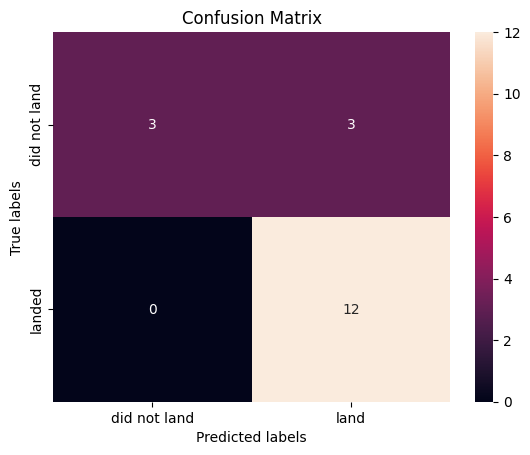

In [12]:
# Plot the confusion matrix
yhat = logreg_cv.predict(X_test)
plot_confusion_matrix(Y_test, yhat)

In [13]:
# Create a support vector machine object and a GridSearchCV object 
parameters = {'kernel':('linear', 'rbf','poly','rbf', 'sigmoid'),
              'C': np.logspace(-3, 3, 5),
              'gamma':np.logspace(-3, 3, 5)}
svm = SVC()
svm_cv = GridSearchCV(svm, parameters, cv = 10)
svm_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=SVC(),
             param_grid={'C': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'gamma': array([1.00000000e-03, 3.16227766e-02, 1.00000000e+00, 3.16227766e+01,
       1.00000000e+03]),
                         'kernel': ('linear', 'rbf', 'poly', 'rbf', 'sigmoid')})

In [14]:
# Display the best parameters and the accuracy on the validation data
print("tuned hyperparameters :(best parameters) ",svm_cv.best_params_)
print("accuracy :",svm_cv.best_score_)

tuned hyperparameters :(best parameters)  {'C': np.float64(1.0), 'gamma': np.float64(0.03162277660168379), 'kernel': 'sigmoid'}
accuracy : 0.8482142857142856


In [15]:
# Calculate the accuracy of the best estimator on the testing data
svm_cv.score(X_test, Y_test)

0.8333333333333334

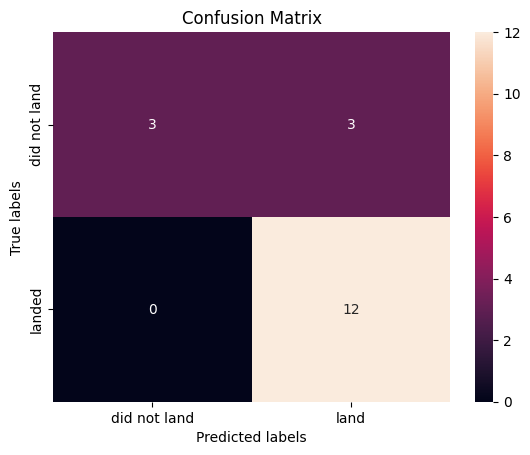

In [16]:
# Plot the confusion matrix of the testing data 
yhat=svm_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [17]:
# Create a Decision Tree object and a GridSearchCV object
parameters = {
    'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': [None, 'sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier()
tree_cv = GridSearchCV(tree, parameters, cv =10, error_score='raise')
tree_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, error_score='raise', estimator=DecisionTreeClassifier(),
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [2, 4, 6, 8, 10, 12, 14, 16, 18],
                         'max_features': [None, 'sqrt'],
                         'min_samples_leaf': [1, 2, 4],
                         'min_samples_split': [2, 5, 10],
                         'splitter': ['best', 'random']})

In [18]:
# Print the best parameters and the best score
print("tuned hpyerparameters :(best parameters) ",tree_cv.best_params_)
print("accuracy :",tree_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'criterion': 'entropy', 'max_depth': 18, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'splitter': 'best'}
accuracy : 0.8767857142857143


In [19]:
# calculate the score of the best estimator on the testing data
tree_cv.score(X_test, Y_test)

0.8333333333333334

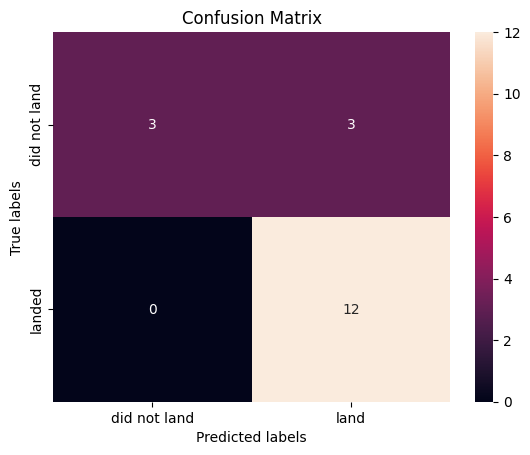

In [20]:
# Plot the confusion matrix of the testing data 
yhat = tree_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

In [21]:
# Create a K Nearest Neighbors object and a GridSearchCV object
parameters = {'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
              'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
              'p': [1,2]}

KNN = KNeighborsClassifier()
knn_cv = GridSearchCV(KNN, parameters, cv = 10)
knn_cv.fit(X_train, Y_train)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(),
             param_grid={'algorithm': ['auto', 'ball_tree', 'kd_tree', 'brute'],
                         'n_neighbors': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
                         'p': [1, 2]})

In [22]:
#  Display the best parameters and the accuracy on the validation data
print("tuned hpyerparameters :(best parameters) ",knn_cv.best_params_)
print("accuracy :",knn_cv.best_score_)

tuned hpyerparameters :(best parameters)  {'algorithm': 'auto', 'n_neighbors': 10, 'p': 1}
accuracy : 0.8482142857142858


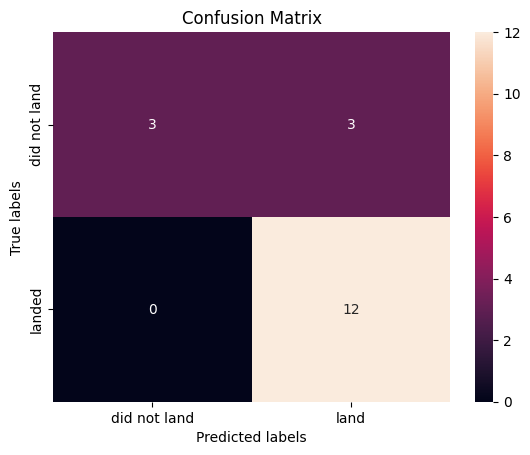

In [23]:
yhat = knn_cv.predict(X_test)
plot_confusion_matrix(Y_test,yhat)

## Find the method performs best:

In [24]:
# Define parameter grids for each model
param_grids = {
    'LogisticRegression': {
        'C'      : [0.01, 0.1, 1], 
        'penalty': ['l2'], 
        'solver' : ['lbfgs']},

    'SVC': {
        'kernel': ('linear', 'rbf', 'poly', 'sigmoid'), 
        'C'     : np.logspace(-3, 3, 5), 
        'gamma' : np.logspace(-3, 3, 5)},

    'DecisionTreeClassifier': {
        'criterion'        : ['gini', 'entropy'], 
        'splitter'         : ['best', 'random'], 
        'max_depth'        : [2*n for n in range(1, 10)], 
        'max_features'     : [None, 'sqrt'], 
        'min_samples_leaf' : [1, 2, 4], 
        'min_samples_split': [2, 5, 10]},

    'KNeighborsClassifier': {
        'n_neighbors'     : [1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 
        'algorithm'       : ['auto', 'ball_tree', 'kd_tree', 'brute'], 
        'p'               : [1, 2]}
}

# Find the best model out of all the classifiers
models = {
    'LogisticRegression'    : LogisticRegression(),
    'SVC'                   : SVC(),
    'DecisionTreeClassifier': DecisionTreeClassifier(),
    'KNeighborsClassifier'  : KNeighborsClassifier()
}

best_estimators = {}

for model_name in models:
    grid_search = GridSearchCV(estimator = models[model_name], param_grid=param_grids[model_name], cv=10)
    grid_search.fit(X_train, Y_train)
    best_estimators[model_name] = grid_search.best_estimator_

# Output the best estimators
for model_name, estimator in best_estimators.items():


    
    print(f"Best {model_name}: {estimator}")

Best LogisticRegression: LogisticRegression(C=0.01)
Best SVC: SVC(C=np.float64(1.0), gamma=np.float64(0.03162277660168379), kernel='sigmoid')
Best DecisionTreeClassifier: DecisionTreeClassifier(max_depth=10, max_features='sqrt', min_samples_split=5,
                       splitter='random')
Best KNeighborsClassifier: KNeighborsClassifier(n_neighbors=10, p=1)


In [25]:
# Output the accuracy of each model on the testing data
models_df = pd.DataFrame({model_name: estimator.score(X_test, Y_test) for model_name, estimator in best_estimators.items()}, index=['Accuracy'])
models_df

,LogisticRegression,SVC,DecisionTreeClassifier,KNeighborsClassifier
Accuracy,0.833333,0.833333,0.888889,0.833333


<Axes: title={'center': 'Accuracy of Models'}>

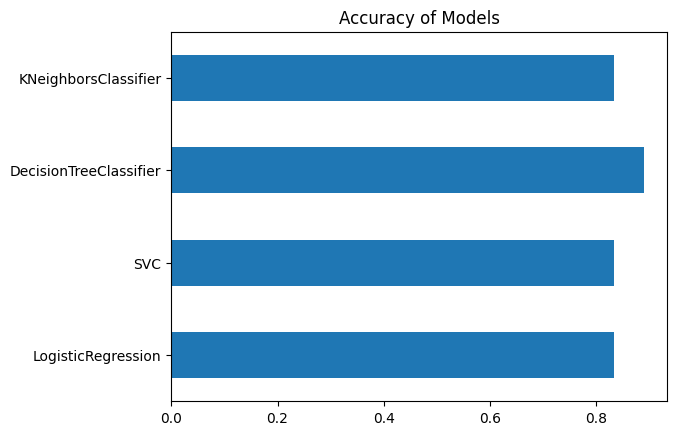

In [26]:
# create a bar plot of the accuracy of the models
models_df.T.plot(kind='barh', title='Accuracy of Models', legend=False)

This Jupyter Notebook was Completed By [Jonathan Scott](http://www.linkedin.com/in/jonathan-scott-140709317) as part of the IBM Data Science Certification.

## Author

[Pratiksha Verma](https://www.linkedin.com/in/pratiksha-verma-6487561b1/)


### <h5 align="center"> IBM Corporation 2022. All rights reserved. <h3/>
